# Transmission mode comparison: cell-free vs cell-to-cell

The standard TIV model assumes infection is mediated entirely by free virus, but for many pathogens (notably HIV and HCV) direct cell-to-cell transmission is an important alternate route. Cell-free transmission requires virus to diffuse through extracellular space and is vulnerable to dilution and neutralizing antibodies; mathematically it scales with the concentration of free virus (T*V). Cell-to-cell transmission occurs when infected and uninfected cells make direct contact (e.g. virological synapses) and is both more efficient per contact and partially resistant to antibodies; it scales with T*I. In this notebook I compare three ODE variants (cell-free only, cell-to-cell only, combined) following the formulation discussed in Graw & Perelson 2016 to ask whether the dominant transmission route changes predicted viral dynamics.

### Cell-free only
$\frac{dT}{dt} = -\beta_f T V$\n
$\frac{dI}{dt} = \beta_f T V - \delta I$\n
$\frac{dV}{dt} = p I - c V$\n

### Cell-to-cell only
$\frac{dT}{dt} = -\beta_c T I$\n
$\frac{dI}{dt} = \beta_c T I - \delta I$\n
$\frac{dV}{dt} = p I - c V$\n

### Combined model
$\frac{dT}{dt} = -\beta_f T V - \beta_c T I$\n
$\frac{dI}{dt} = \beta_f T V + \beta_c T I - \delta I$\n
$\frac{dV}{dt} = p I - c V$\n

| Symbol | Meaning | Unit | Value | Source |
| --- | --- | --- | --- | --- |
| $\beta_f$ | cell-free infection rate | mL / TCID50 / day | 3.2e-5 | Baccam 2006 |
| $\beta_c$ | cell-to-cell infection rate | mL / cell / day | 1e-7 | calibrated |
| $\delta$ | infected cell death rate | 1/day | 4.0 | Baccam 2006 |
| $p$ | virus production per infected cell | TCID50/cell/day | 4.6e-2 | Baccam 2006 |
| $c$ | viral clearance rate | 1/day | 5.2 | Baccam 2006 |
| $T_0$ | initial target cells | cells | 4e8 | Baccam 2006 |
| $V_0$ | initial free virus | TCID50/mL | 75 | Baccam 2006 |

beta_c was calibrated so that at peak infection both routes contribute comparably. In practice the ratio beta_c/beta_f is poorly constrained by viral-load-only data — a known identifiability problem discussed in Graw & Perelson 2016.

Cell-to-cell R0 has a simpler form because transmission depends on cell contact (T*I) and not on production or clearance of free virus. Thus p and c do not enter the invasion threshold for direct transmission — an important biological insight: if cell-to-cell dominates, targeting free-virus production or clearance has limited effect on the initial invasion.

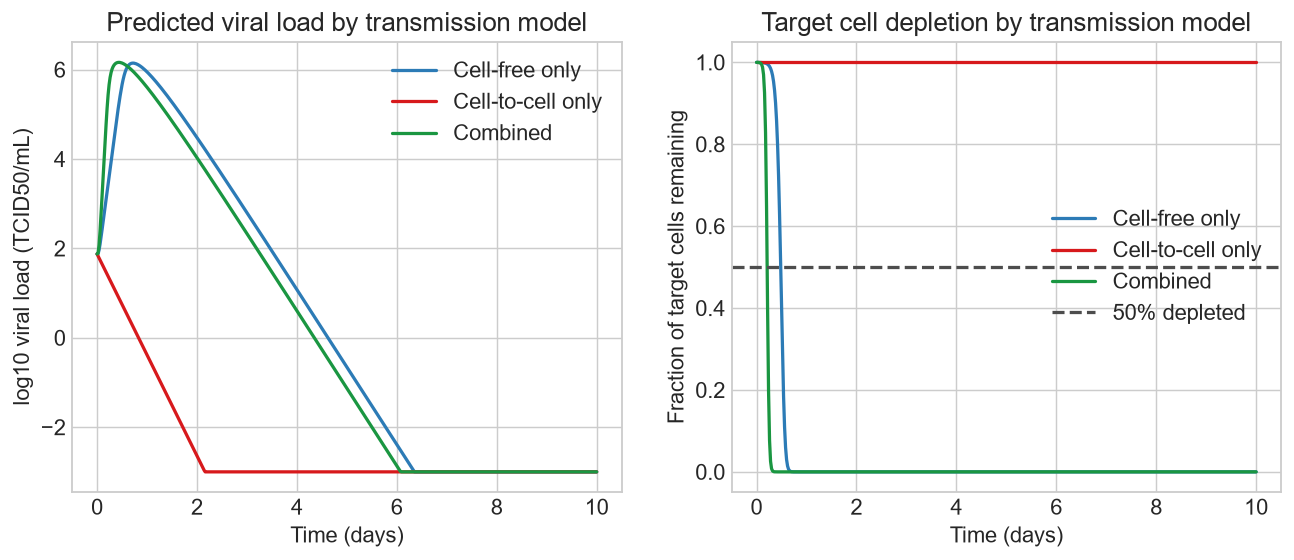

In [7]:
t_eval = np.linspace(0, 10, 500)
y0 = [T0, 0.0, V0]
sol_cf = solve_model(tiv_cellfree, (beta_f, delta, p, c), (0, 10), t_eval, y0=y0)
sol_cc = solve_model(tiv_celltocell, (beta_c, delta, p, c), (0, 10), t_eval, y0=y0)
sol_comb = solve_model(tiv_combined, (beta_f, beta_c, delta, p, c), (0, 10), t_eval, y0=y0)

V_cf = np.maximum(sol_cf.y[2], 1e-3)
V_cc = np.maximum(sol_cc.y[2], 1e-3)
V_comb = np.maximum(sol_comb.y[2], 1e-3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# Left: viral load
axes[0].plot(t_eval, np.log10(V_cf), color=COLORS['cellfree'], label='Cell-free only')
axes[0].plot(t_eval, np.log10(V_cc), color=COLORS['celltocell'], label='Cell-to-cell only')
axes[0].plot(t_eval, np.log10(V_comb), color=COLORS['combined'], label='Combined')
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('log10 viral load (TCID50/mL)')
axes[0].set_title('Predicted viral load by transmission model')
axes[0].legend()

# Right: target cell fraction
T_cf = sol_cf.y[0] / T0
T_cc = sol_cc.y[0] / T0
T_comb = sol_comb.y[0] / T0
axes[1].plot(t_eval, T_cf, color=COLORS['cellfree'], label='Cell-free only')
axes[1].plot(t_eval, T_cc, color=COLORS['celltocell'], label='Cell-to-cell only')
axes[1].plot(t_eval, T_comb, color=COLORS['combined'], label='Combined')
axes[1].axhline(0.5, color='0.3', linestyle='--', label='50% depleted')
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Fraction of target cells remaining')
axes[1].set_title('Target cell depletion by transmission model')
axes[1].legend()

output_path = project_dir / 'figures' / '01_three_model_comparison.png'
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

Next, I varied the relative strength of each route (the ratio beta_c / beta_f) to map how viral dynamics change across the spectrum from purely cell-free to predominantly cell-to-cell transmission.

As cell-to-cell transmission becomes stronger, peak viral load tends to increase and clearance time can shorten because infections amplify more rapidly and burn through target cells faster; the relationship is not strictly linear and depends on parameter trade-offs. A shorter clearance time with a higher peak suggests a more intense but shorter infection, which may have different clinical implications than a low-grade persistent infection. Drugs that target only cell-free virus will be less effective when cell-to-cell transmission dominates, because the dominant invasion pathway is not affected.

Drug B (targeting cell-free infection) is largely ineffective against cell-to-cell transmission: even with epsilon=0.9 the combined model can sustain infection because beta_c is unchanged. Drug A (reducing p) can be more effective because it reduces overall viral output, but if cell-to-cell dominates production-independent transmission remains an issue. This has clinical relevance for pathogens where tissue-compartment cell-to-cell spread is important and highlights why quantifying transmission mode matters beyond academic interest.

1. Nowak MA, Bangham CRM (1996). Population dynamics of immune responses to persistent viruses. Science 272:74–79.
2. Baccam P, Beauchemin C, Macken CA, Hayden FG, Perelson AS (2006). Kinetics of influenza A virus infection in humans. Journal of Virology 80:7590–7599.
3. Graw F, Perelson AS (2016). Modeling viral spread. Annual Review of Virology 3:555–572.
4. Gabel A, Szczurek E, Rateitschak K, Wolkenhauer O, Graw F (2019). FAMoS: A flexible algorithm for model selection. PLOS Computational Biology 15:e1007230.